<a href="https://colab.research.google.com/github/expely/Business-Analytics-Labs/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [20]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read csv
df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2020/2020-02-11/hotels.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1. Initially I'm seeing that instead of nulls, I'm seeing columns with `NaN` (sepcifically in agent/company). Also, the first two rows for `adr` have a 0 in them, which probably is not the actual case. But, instead of being null, it's imputed with 0s.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [21]:
# Import scaling
from sklearn.preprocessing import StandardScaler

# Select and scale features
features = ['lead_time', 'total_of_special_requests', 'booking_changes', 'previous_cancellations']
segment_df = df[features].copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(segment_df)

# Convert to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df.describe()

,lead_time,total_of_special_requests,booking_changes,previous_cancellations
count,1.193900e+05,1.193900e+05,1.193900e+05,1.193900e+05
mean,6.094277e-17,-5.332493e-17,3.428031e-17,-3.142362e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-9.733187e-01,-7.206941e-01,-3.389899e-01,-1.031795e-01
25%,-8.048782e-01,-7.206941e-01,-3.389899e-01,-1.031795e-01
50%,-3.276301e-01,-7.206941e-01,-3.389899e-01,-1.031795e-01
75%,5.239303e-01,5.406659e-01,-3.389899e-01,-1.031795e-01
max,5.923385e+00,5.586106e+00,3.185465e+01,3.069036e+01


### ✍️ Your Response: 🔧
1. `lead_time` was to better understand how far in advance customers plan for (and if there are groupings there). Booking Changes follows the same logic, but to know if they are changing things far in advance, last minute, or many times over. Special Requests is a similar idea, to better represent customers who are picky/needy. And previous cancellations is to konw about repeat customers who had to cancel, but ended up coming back.

2. I'm expecting to see ideas of lower lead times is going be grouped with increase booking changes as customers don't who are impulsive and bought a trip last minute are also going to change it a lot. Special Requests will be interesting because if it's grouped with higher lead times, we can think people are well-planned out and knew what requests they need, or are impulisve and have lower lead times so they make a lot of requests.


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



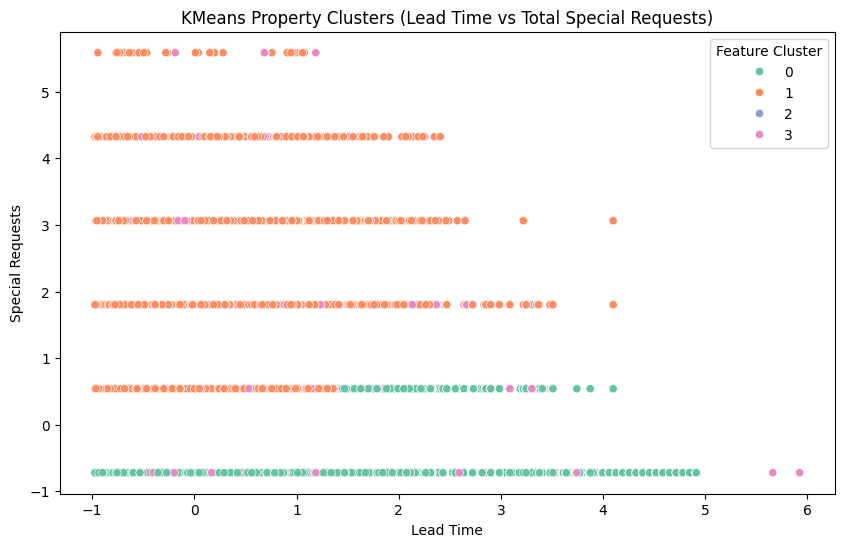

In [22]:
from sklearn.cluster import KMeans

# Select the standardized features
X_feat = scaled_df[features]

# Apply KMeans clustering with 4 clusters
kmeans_feat = KMeans(n_clusters=4, random_state=1)
scaled_df['feature_cluster'] = kmeans_feat.fit_predict(X_feat)

# Plot lead times vs total special requests colored by feature cluster
plt.figure(figsize=(10,6))
sns.scatterplot(data=scaled_df,
                x='lead_time',
                y='total_of_special_requests',
                hue='feature_cluster',
                palette='Set2')

plt.title("KMeans Property Clusters (Lead Time vs Total Special Requests)")
plt.xlabel("Lead Time")
plt.ylabel("Special Requests")
plt.legend(title='Feature Cluster')
plt.show()

### ✍️ Your Response: 🔧
1. I chose a k of 4, because there were enough variables that 2 or 3 would be too low. We want to be able to target more than just 2 types of customers, but don't want to be overwhelmed by the options.

2. There seems to be customers grouped into a few different ways. Relative to lead_time, group two seems to have more requests, regardless of lead time, with no group standing out as having more than others. Except Group 0, which consistently has the lowest number of special requests. It seems group 2 and 3 don't have as much data for special requests.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


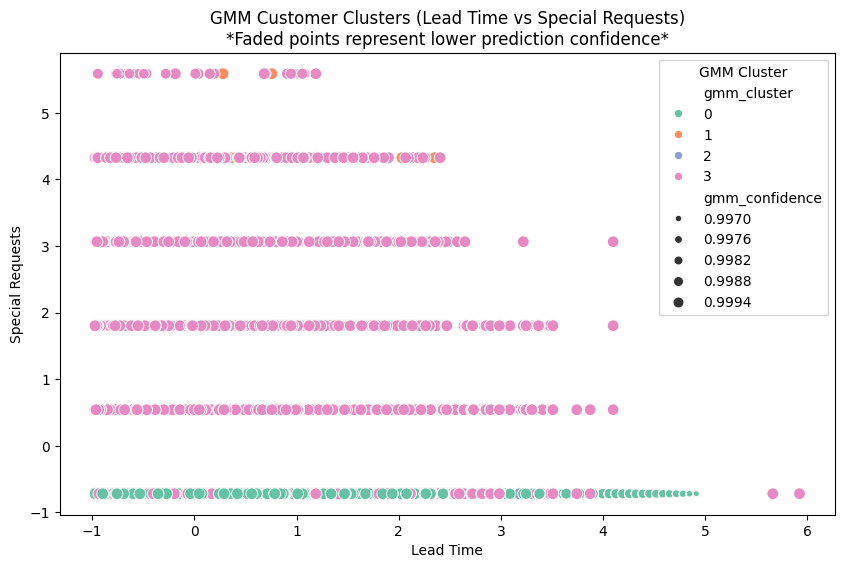

In [23]:
from sklearn.mixture import GaussianMixture

# Apply Gausian Mixture Model with Soft Clusters
gmm_feat = GaussianMixture(n_components=4, random_state=1).fit(X_feat)
soft_clusters = gmm_feat.predict_proba(X_feat)

scaled_df['gmm_cluster'] = soft_clusters.argmax(axis=1)
scaled_df['gmm_confidence'] = soft_clusters.max(axis=1)

# Visualize the GMM model
plt.figure(figsize=(10,6))
sns.scatterplot(data=scaled_df,
                x='lead_time',
                y='total_of_special_requests',
                hue='gmm_cluster',
                size='gmm_confidence',
                palette='Set2')

plt.title("GMM Customer Clusters (Lead Time vs Special Requests)\n*Faded points represent lower prediction confidence*")
plt.xlabel("Lead Time")
plt.ylabel("Special Requests")
plt.legend(title='GMM Cluster')
plt.show()

### ✍️ Your Response: 🔧
1.  It ended up being very similar, but with some differences around the in-between variables. E.g., Cluster 3 (which seems to have replaced cluster 1 in the KMeans) is shown when special requests are above 0 far more decisively. And Cluster 0 doesn't have any above 0.

2. "Who are the most prototypical customers"? Using the confidence we can understand which customers know who they are and are truly represented. Like Cluster 3 is almost always going to make a special request, how can we take advantage of that or use that knowledge to gain a competitive advantage?


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [24]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Create a 10,000 row sample to save computation time
X_sample = X_feat.sample(n=10000, random_state=42)

# Predict labels for the sample
kmeans_sample_labels = kmeans_feat.predict(X_sample)

# KMeans Scores
kmeans_centers = kmeans_feat.cluster_centers_
kmeans_wcss = np.sum((X_sample - kmeans_centers[kmeans_sample_labels]) ** 2).sum()

kmeans_silhouette = silhouette_score(X_sample, kmeans_sample_labels)
kmeans_db = davies_bouldin_score(X_sample, kmeans_sample_labels)

# Predict hard labels for the sample
gmm_sample_labels = gmm_feat.predict(X_sample)

# GMM Scores
gmm_centers = gmm_feat.means_
gmm_wcss = np.sum((X_sample - gmm_centers[gmm_sample_labels]) ** 2).sum()

gmm_silhouette = silhouette_score(X_sample, gmm_sample_labels)
gmm_db = davies_bouldin_score(X_sample, gmm_sample_labels)

# --- Print Results ---
print("--- KMeans Metrics ---")
print(f"WCSS: {kmeans_wcss:.2f}")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_db:.4f}\n")

print("--- GMM Metrics ---")
print(f"WCSS: {gmm_wcss:.2f}")
print(f"Silhouette Score: {gmm_silhouette:.4f}")
print(f"Davies-Bouldin Index: {gmm_db:.4f}")

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


--- KMeans Metrics ---
WCSS: 18290.91
Silhouette Score: 0.3795
Davies-Bouldin Index: 0.8431

--- GMM Metrics ---
WCSS: 30473.15
Silhouette Score: 0.2806
Davies-Bouldin Index: 1.8160


### ✍️ Your Response: 🔧
1. Kmeans was better for WCSS, Silhouette Score, and Savies-Bouldin. But, that makes sense given that KMeans is meant to create the most perfect clusters.

2. Probably KMeans to start, as not only is it simpler to use and explain to business leaders (should that time arise), but also for this case there is a lot less ambiguity between personas. GMM should be used when the business problem inherently has uncertainty in it.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [25]:
# Attach KMeans cluster labels to dataframe
df['cluster_label'] = kmeans_feat.labels_

# Calculate the mean of the chosen features for each cluster
cluster_profiles = df.groupby('cluster_label')[features].mean()

# Sort the clusters by a defining feature (e.g., lead_time) to make comparisons easier
cluster_profiles_sorted = cluster_profiles.sort_values(by='lead_time', ascending=False)

# Display the neatly formatted profiles
display(cluster_profiles_sorted)

,lead_time,total_of_special_requests,booking_changes,previous_cancellations
cluster_label,,,,
2,229.703448,0.000000,0.006897,21.979310
0,120.747930,0.028432,0.107549,0.085051
3,108.035920,0.740182,2.548855,0.012284
1,76.968949,1.400986,0.117836,0.027968


### ✍️ Your Response: 🔧
1. Cluster 2 can be seen as an "indecisive go getter" having the highest lead time, and the highest previous_cancellations by far. They plan far in advance, but it also means that they are likely to cancel for something else that comes up in the mean time. They don't make special requests or booking changes. Cluster 0 has a good amount of lead time as well, but is more the average customer, they rarely cancel, have some special requests, and every once in awhile make a booking change. Cluster 3 is just indecisive, they have a decently high lead time, and make a lot of booking changes, with higher than normal special requests. Cluster 1 is Needy and impulsive, with a low lead_time they book fast, and have a lot of special requests.

2. Cluster 2, the hotel can create promotions that keep them excited to go on the trip. Because they are way more likely to cancel, and plan early, offering them more things for free in the coming months leading to their trip will keep their engagement high. Cluster 0 seems to be our ideal customer, so we should make sure any new strategies doesn't conflict with this customer. Cluster 3 should offer flexible rates, since they change a lot of bookings. Cluster 1 we should upsell as they are not likely to cancel, and likely to make special requests, so we should upsell them as they're going to be needy from the beginning.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. The hardest part was trying to figure out what the different clusters meant. Part 6 really helped me with visualizing all of the clusters and how they interact with one another. But, before I didn't have any idea how to understand the raw numbers of the different clusters.

2. When you don't know what you're looking for. If you just want to figure out who your current set of customers are, this is a great way to mathematically figure that out. From there we can build personas and start looking into supervised models. I think this is a great foundation for building a data analytics strategy in a company.

3. Imagine that you have a lot of data about your customers, but you don't know who they are or what they want. It's hard to fit the specific needs of every human being, but they often fit into different personas, groups, cliques, etc. We want to be able to figure out these personas based on this data, and the data that is most in our control. So, we can use the statistical technique of clustering to figure out who our different groups of customers are around the chosen data. Now, we can start targeting specific segments of the market or even differentiating towards specific markets.

4. This is just another step closer! This is where the value of python starts to really shine! In Excel there are quite a few supervised learning models built in, but not a lot of unsupervised (or, if there are, it's hard to change the data and come back to it to really understand the models). Now, I can reproduce unsupervised clustering models in Python which is way faster than if I tried to do the same in Excel.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [26]:
!jupyter nbconvert --to html "assignment_09_clustering.ipynb"

[NbConvertApp] Converting notebook assignment_09_clustering.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 561062 bytes to assignment_09_clustering.html
